# Ayudantía 5: ANOVA test


Para abrir con Google Colab: <a target="_blank" href="https://githubtocolab.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/Ayudantias/Ayudantia5_TestDeHipotesisANOVA.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [26]:
!pip install -q statsmodels 
!pip install -q seaborn 
!pip install -q pingouin

# Análisis de Datos Categóricos

In [27]:
import scipy.stats as st
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1.

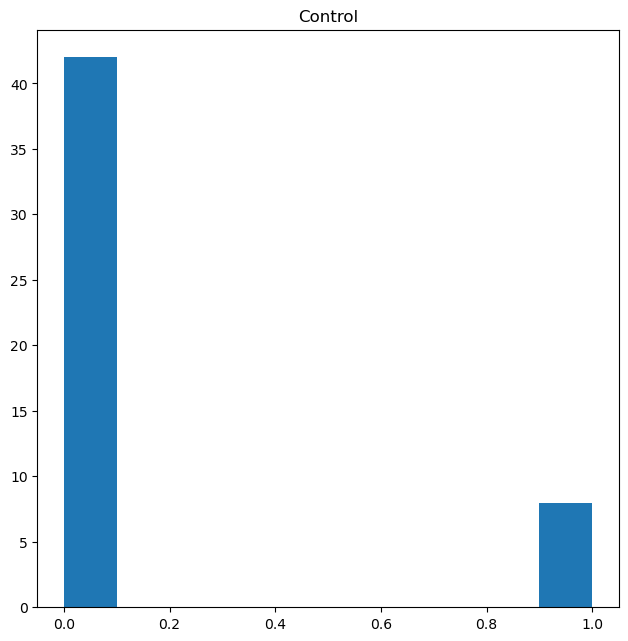

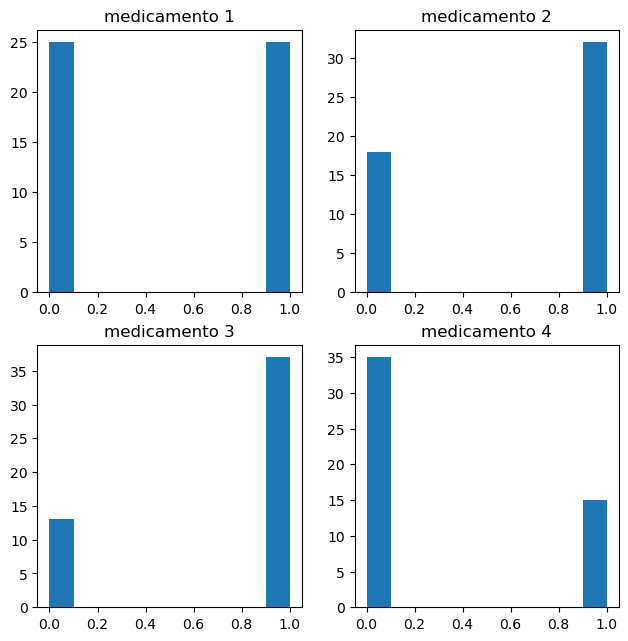

In [28]:
np.random.seed(42)
control = st.bernoulli.rvs(p = 0.2, size = 50)
medicamento1 = st.bernoulli.rvs(p = 0.5, size = 50)
medicamento2 = st.bernoulli.rvs(p = 0.55, size = 50)
medicamento3 = st.bernoulli.rvs(p = 0.75, size = 50)
medicamento4 = st.bernoulli.rvs(p = 0.3, size = 50)
fig, ax = plt.subplots(dpi = 100, figsize = (7.5,7.5))
ax.hist(control)
ax.set_title('Control')
plt.show()
fig, ax = plt.subplots(2,2,dpi = 100, figsize = (7.5,7.5))
ax[0,0].hist(medicamento1)
ax[0,0].set_title('medicamento 1')
ax[0,1].hist(medicamento2)
ax[0,1].set_title('medicamento 2')
ax[1,0].hist(medicamento3)
ax[1,0].set_title('medicamento 3')
ax[1,1].hist(medicamento4)
ax[1,1].set_title('medicamento 4')
plt.show()

Hipótesis nula y alternativa, estime la
proporción muestral y resporte:
- Valor del estadístico P0.
- Intervalo de confianza del 95% la población.
- Valor-p de la prueba.
- Si rechaza o falla en rechazar la hipótesis nula.
---

En todos los casos las hipótesis se plantean como:
$$
H_0: p_i = 0.5
$$
$$
H_a: p_i > 0.5
$$
Donde $p_i$ es la proporción de la población de la cual provienen los datos.

In [29]:
import pandas as pd
p0 = 0.5 # estadistico a comparar
n = 50 # cantidad de datos
signifi = 0.05 # significancia alpha = 0.05

# precreamos el dataframe
resultados = pd.DataFrame(index=['p_hat', 'z0', 'CI Low', 'CI Up', 'p-val(Z_0)', 'p-val(Binom)'],
                         columns=['control', 'medicamento1', 'medicamento2', 'medicamento3', 'medicamento4'],
                         dtype=object)

# calculamos el p_hat 
resultados.loc['p_hat'] = [control.mean(), medicamento1.mean(),
                           medicamento2.mean(), medicamento3.mean(),
                           medicamento4.mean()]

# loop de cada dato
for data, name in zip([control, medicamento1, medicamento2,
                       medicamento3, medicamento4],
                       ['control', 'medicamento1', 'medicamento2',
                        'medicamento3', 'medicamento4']
                    ):
    p_hat= resultados.loc['p_hat', name]
    # calculamos el estadístico de la prueba
    z0 = (p_hat - p0) / np.sqrt(p0 * (1-p0)/n)
    resultados.loc['z0', name] = z0
    # CI inferior
    ci_up = p_hat + st.norm.ppf(1 - 0.05/2) * np.sqrt((p_hat*(1-p_hat))/(n))
    # CI sup
    ci_low = p_hat - st.norm.ppf(1 - 0.05/2) * np.sqrt((p_hat*(1-p_hat))/(n))

    resultados.loc['CI Low', name] = ci_low
    resultados.loc['CI Up', name] = ci_up
    # valor p
    resultados.loc['p-val(Z_0)', name] = 1 - st.norm.cdf(z0)
    resultados.loc['p-val(Binom)', name] = st.binomtest(data.sum(), n = n, p = p0, alternative = 'greater').pvalue
    # prueba de la hipótesis

resultados.T

,p_hat,z0,CI Low,CI Up,p-val(Z_0),p-val(Binom)
control,0.16,-4.808326,0.058384,0.261616,0.999999,1.0
medicamento1,0.5,0.0,0.36141,0.63859,0.5,0.556138
medicamento2,0.64,1.979899,0.506953,0.773047,0.023857,0.032454
medicamento3,0.74,3.394113,0.618419,0.861581,0.000344,0.000468
medicamento4,0.3,-2.828427,0.17298,0.42702,0.997661,0.998699


## 2.

Compare cada grupo de tratamiento con el grupo de control para determinar si existe evidencia estadística suficiente que permita afirmar que la proporción de éxito es mayor en cada tratamiento respecto al control. Indique cuáles de sus medicamentos posee una diferencia significativa con el grupo control.

---

En este caso se debe realizar un método similar al anterior, pero en este caso, se compara con la muestra control.

En cada caso, las hipótesis son:

$$
H_0: p_i = p_c
$$
$$
H_a: p_i > p_c
$$

Donde $p_c$ es la proporción del grupo control.

In [52]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

p_c = np.mean(control)
n = 50
signifi = 0.05

resultados = pd.DataFrame(
    index=['p_hat', 'z0', 'CI Low', 'CI Up', 'p-val(Z_0)'],
    columns=['medicamento1', 'medicamento2', 'medicamento3', 'medicamento4'],
    dtype=object
)

resultados.loc['p_hat'] = [medicamento1.mean(), medicamento2.mean(),
                           medicamento3.mean(), medicamento4.mean()]

for data, name in zip(
    [medicamento1, medicamento2, medicamento3, medicamento4],
    ['medicamento1', 'medicamento2', 'medicamento3', 'medicamento4']
):
    count = np.array([int(data.sum()), int(control.sum())])
    nobs  = np.array([len(data), len(control)])

    z_i, p_i = proportions_ztest(count, nobs, alternative='larger')
    resultados.loc['z0', name] = z_i

    p1, p2 = count / nobs
    z_crit = st.norm.ppf(0.975)
    se = np.sqrt(p1*(1-p1)/nobs[0] + p2*(1-p2)/nobs[1])
    resultados.loc['CI Low', name] = p1 - p2 - z_crit * se
    resultados.loc['CI Up', name]  = p1 - p2 + z_crit * se

    resultados.loc['p-val(Z_0)', name] = p_i

resultados.T

,p_hat,z0,CI Low,CI Up,p-val(Z_0)
medicamento1,0.5,3.615385,0.168148,0.511852,0.00015
medicamento2,0.64,4.898979,0.312586,0.647414,0.0
medicamento3,0.74,5.829219,0.421546,0.738454,0.0
medicamento4,0.3,1.66337,-0.022665,0.302665,0.048119


## 3
Entre los tratamientos que muestran mayor efectividad, seleccione aquellos que deben avanzar a estudios en humanos. Compare los medicamentos entre sí e identifique el tratamiento
con mayor eficacia relativa dentro del conjunto de medicamentos probados.

---

Para este tipo de estudios es necesario comparar cada muestra con la siguiente. Para esto es necesario realizar pairwise comparisons.

In [53]:
pairwise_comp = pd.DataFrame(index=[1, 2, 3, 4], columns=[1, 2, 3, 4])
data = [medicamento1, medicamento2, medicamento3, medicamento4]
for i in pairwise_comp.columns:
    for j in pairwise_comp.index:
        count_ij = np.array([int(data[i-1].sum()), int(data[j-1].sum())])
        nobs_ij  = np.array([len(data[i-1]), len(data[j-1])])
        _, p_val = proportions_ztest(count_ij, nobs_ij, alternative='larger')
        pairwise_comp.loc[i, j] = p_val
pairwise_comp

,1,2,3,4
1,0.5,0.921308,0.993287,0.020613
2,0.078692,0.5,0.860173,0.000329
3,0.006713,0.139827,0.5,0.000005
4,0.979387,0.999671,0.999995,0.5


Podemos ver que es mayor a 1, 4. Y que 2 es mayor a 1 y 4. Pero hay una mayor incertidumbre entre 2 y 3.

# ANOVA

## 1.

Genere visualizaciones apropiadas que permitan comparar los rendimientos entre los tratamientos. A simple vista ¿Es posible observar diferencias significativas en los diferentes
tratamientos?


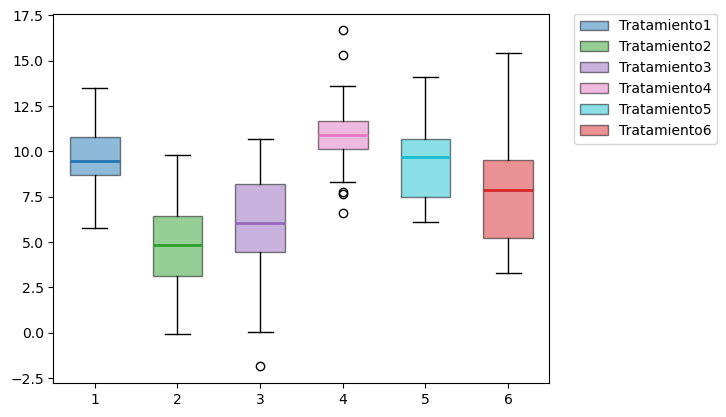

In [54]:
# Datos

np.random.seed(42)
tratamiento1 = st.norm.rvs(loc = 10, scale = 2.2, size = 30)
tratamiento2 = st.norm.rvs(loc = 5, scale = 2.6, size = 30)
tratamiento3 = st.norm.rvs(loc = 6, scale = 3, size = 30)
tratamiento4 = st.norm.rvs(loc = 11, scale = 2.3, size = 30)
tratamiento5 = st.norm.rvs(loc = 9.5, scale = 2.1, size = 30)
tratamiento6 = st.norm.rvs(loc = 7, scale = 3.1, size = 30)
fig, ax = plt.subplots(dpi = 100)
colors = ['tab:blue', 'tab:green', 'tab:purple', 'tab:pink', 'tab:cyan', 'tab:red']
for i, trat in enumerate([tratamiento1, tratamiento2, tratamiento3, tratamiento4, tratamiento5, tratamiento6]):
    ax.boxplot(
        trat,
        positions = [i],
        widths = 0.6,
        patch_artist = True,
        boxprops = dict( facecolor = colors[i], alpha = 0.5),
        medianprops = dict(color = colors[i], linewidth = 2),
        label = 'Tratamiento' + str(i+1)
    )
ax.set_xticklabels([1,2,3,4,5,6])
ax.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0.)



## 2.
En base a la visualización anterior, que puede afirmar con respecto a la varianza que posee cada grupo. Realice una prueba estadística que le permita evaluar si la varianza entre grupos es la misma o no. ¿Qué consecuencias tiene la homocedasticidad y heterocedasticidad en un test ANOVA?

---

En este caso debemos realizar un test de Levene. Este test permite evaluar si dos o más muestras poseen la misma varianza.

In [55]:
levene = st.levene(tratamiento1, tratamiento2, tratamiento3,
                   tratamiento4, tratamiento5, tratamiento6)
# si p-value < alpha, entonces no se cumple la homocedasticidad. 
# queremos que p-value > alpha para cumplir la homocedasticidad.
print(f'p-value: {levene.pvalue}')

p-value: 0.1531576663377423


La homocedasticidad de la prueba ANOVA viene del hecho de que en la hipótesis nula se asume que cada muestra viene de una misma población. La comparación de dos estimadores de la varianza poblacional (MSE y MStreatment) hace que cuando no se cumpla homocedasticidad, las conclusiones pueden ser erroneas.


## 3.

Aplique tanto una metodología visual como un test de hipótesis para verificar si los datos en cada grupo siguen una distribución normal. ¿Qué consecuencias tiene en el test ANOVA
la utilización de datos no-normales?

---

En esta caso aplicamos el test de Shapiro-Wilk, el cual es un test de hipótesis que permite definir si una muestra proviene de una distribución normal. En particular, la hipótesis nula define que los datos son normales, y la alternativa que son no-normales.

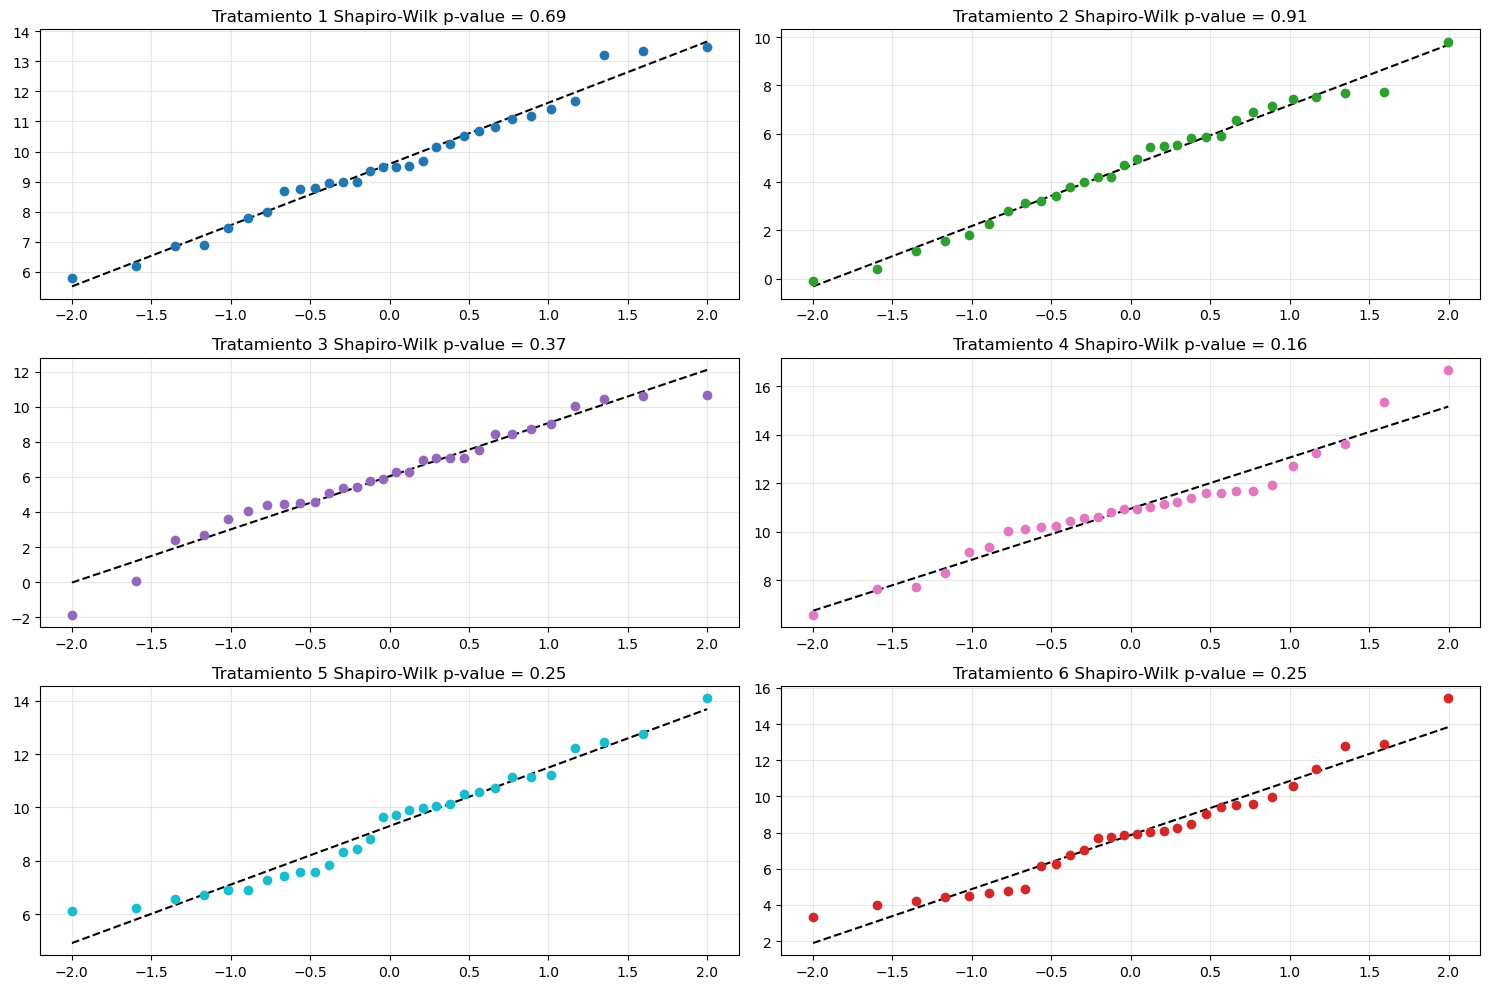

In [34]:
import scipy.stats as st
fig, ax = plt.subplots(3,2, dpi = 100, figsize = (15,10))
i,j = 0,0
for c, trat in enumerate([tratamiento1, tratamiento2, tratamiento3, tratamiento4, tratamiento5, tratamiento6]):
    (osm, osr), (slope, intercept, r) = st.probplot(trat)
    ax[i,j].scatter(osm, osr, color = colors[c], zorder = 3)
    ax[i,j].plot(osm, slope*osm + intercept, color = 'k', linestyle = '--', zorder = 2)
    ax[i,j].grid(alpha = 0.3, zorder = 0)
    shapiro_trat = st.shapiro(trat)
    ax[i,j].set_title(f'Tratamiento {c+1} Shapiro-Wilk p-value = {shapiro_trat.pvalue:.2f}')
    if j == 1:
        j = 0
        i += 1
    else:
        j += 1
fig.tight_layout()

## 4.

Realice un análisis de varianza (ANOVA) para determinar si existen diferencias estadísticamente significativas entre los tratamientos. Presente una tabla ANOVA con los valores relevantes. ¿Qué se puede concluir respecto a
la efectividad de los tratamientos?

In [35]:
# generamos el dataframe
df_plant = pd.DataFrame(columns = ['Tratamiento', 'Rendimiento'])
df_plant['Tratamiento'] = np.repeat([1,2,3,4,5,6], 30)
df_plant['Rendimiento'] = np.concatenate([tratamiento1, tratamiento2, tratamiento3,
                                          tratamiento4, tratamiento5, tratamiento6])
df_plant

,Tratamiento,Rendimiento
0,1,11.092771
1,1,9.695819
2,1,11.424915
3,1,13.350666
4,1,9.484863
...,...,...
175,6,9.564268
176,6,7.040306
177,6,11.505956
178,6,6.179564


In [36]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

modelo = ols('Rendimiento ~ C(Tratamiento)', data = df_plant).fit()
tabla = anova_lm(modelo)
tabla

,df,sum_sq,mean_sq,F,PR(>F)
C(Tratamiento),5.0,832.620694,166.524139,27.557067,1.716351e-20
Residual,174.0,1051.461670,6.042883,NaN,NaN


Rechazamos la hipótesis nula de ANOVA, es decir existe al menos un tratamiento que causa un efecto en el rendimiento del experimento.

ANOVA no dice cuál es, ni la significancia de la diferencia :(


In [37]:
## alternativa
from pingouin import anova
# lo bueno de usar pingouin es que es mas entendible que el ~C...
anova(data = df_plant, dv = 'Rendimiento', between = 'Tratamiento', detailed=True) # y obtenemos lo mismo ;)

,Source,SS,DF,MS,F,p_unc,np2
0,Tratamiento,832.620694,5,166.524139,27.557067,1.716351e-20,0.441924
1,Within,1051.461670,174,6.042883,NaN,NaN,NaN


## 5.

Analice los residuos del modelo ajustado con ANOVA. Evalúe gráficamente y estadísticamente si los supuestos del modelo se cumplen. ¿Qué consecuencias trae que los residuos incumplan dichos supuestos?

---

El residuo en este caso es la diferencia entre el dato medido y el dato predicho, lo cual tiene sentido dado a que ANOVA es un modelo lineal.
Así:
$$
e_{ij}  = y_{ij} - \hat{y}_{ij}
$$
Y si recordamos, en un modelo de experimental CDR $ \hat{y}_{ij} = \overline{y}_i$, debido a que capturamos el efecto medio.

Para hacer esto en `python` hay que trabajar con el modelo lineal de ANOVA.


In [38]:
residuos = modelo.resid
df_plant['residuos'] = residuos

Text(0, 0.5, 'Residuos')

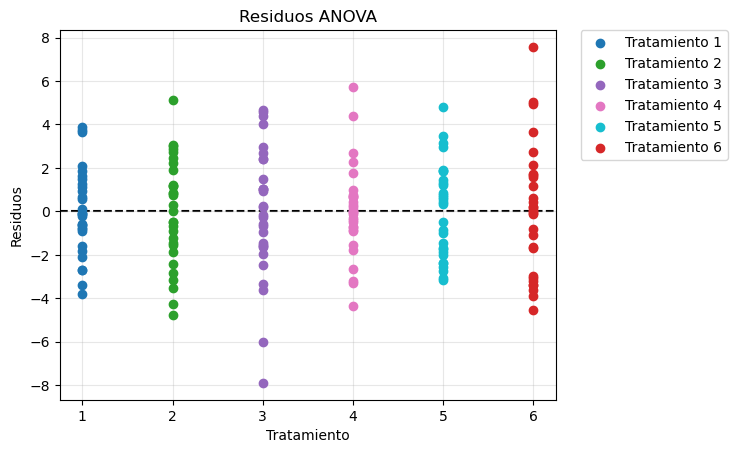

In [39]:
fig, ax = plt.subplots(dpi = 100)

for i in df_plant['Tratamiento'].unique():
    df_trat = df_plant[df_plant['Tratamiento'] == i]
    ax.scatter(df_trat['Tratamiento'], df_trat['residuos'], color = colors[i-1], label = f'Tratamiento {i}',
               zorder = 2)
ax.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0.)
ax.grid(alpha = 0.3, zorder = 0)
ax.axhline(0, color = 'k', linestyle = '--', zorder = 1)
ax.set_title('Residuos ANOVA')
ax.set_xlabel('Tratamiento')
ax.set_ylabel('Residuos')
#

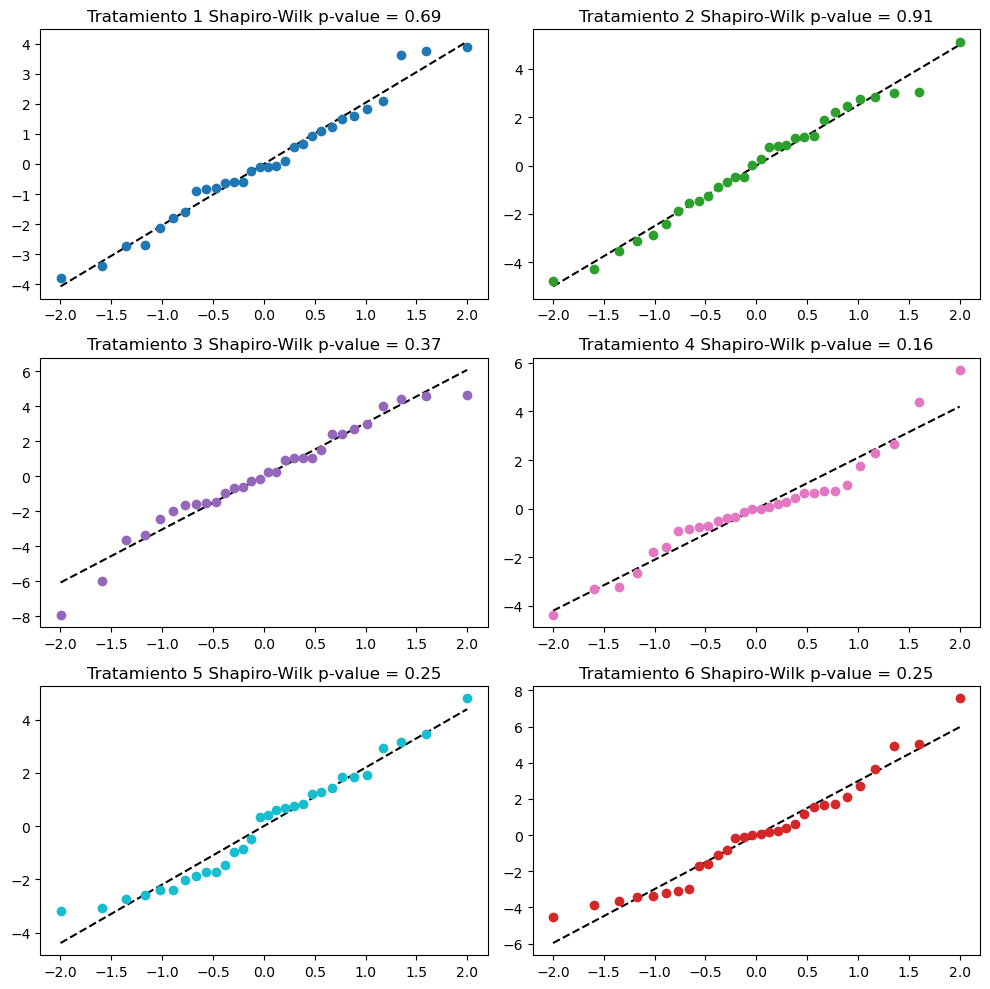

In [40]:
fig, ax = plt.subplots(3,2,dpi = 100, figsize = (10,10))
i,j = 0,0
for trat in df_plant['Tratamiento'].unique():
    df_trat = df_plant[df_plant['Tratamiento'] == trat]
    shapiro_trat = st.shapiro(df_trat['residuos'])
    (osm, osr), (slope, intercept, r) = st.probplot(df_trat['residuos'])
    ax[i,j].scatter(osm, osr, color = colors[trat-1], zorder = 3)
    ax[i,j].plot(osm, osm*slope + intercept, color = 'k', linestyle = '--', zorder = 2)
    ax[i,j].grid(alpha = 0)
    ax[i,j].set_title(f'Tratamiento {trat} Shapiro-Wilk p-value = {shapiro_trat.pvalue:.2f}')
    if j == 1:
        j = 0
        i += 1
    else:
        j += 1
fig.tight_layout()


## 6.
Realice una prueba post-hoc adecuada para identificar específicamente qué pares de tratamientos presentan diferencias significativas. ¿Cuál tratamiento parece ser el más efectivo en
términos de rendimiento?

---
En este caso podemos utilizar dos metodologías. pairwise t-test y TukeyHSD.

En este caso utilizaremos la librería `pingouin` debido a que la función de pairwise t-test sigue siendo experimental en `statsmodels` y la documentación es poco clara.


In [41]:
modelo.t_test_pairwise('C(Tratamiento)', method = 'bonferroni').result_frame

,coef,std err,t,P>|t|,Conf. Int. Low,Conf. Int. Upp.,pvalue-bonferroni,reject-bonferroni
2-1,-4.901099,0.634712,-7.721773,8.652382e-13,-6.153824,-3.648374,1.297857e-11,True
3-1,-3.547423,0.634712,-5.589030,8.680018e-08,-4.800147,-2.294698,1.302003e-06,True
4-1,1.367344,0.634712,2.154277,3.259393e-02,0.114619,2.620069,4.889090e-01,False
5-1,-0.285489,0.634712,-0.449793,6.534195e-01,-1.538214,0.967236,1.000000e+00,False
6-1,-1.721838,0.634712,-2.712788,7.342400e-03,-2.974563,-0.469113,1.101360e-01,False
3-2,1.353677,0.634712,2.132743,3.434797e-02,0.100952,2.606402,5.152195e-01,False
4-2,6.268444,0.634712,9.876050,1.526952e-18,5.015719,7.521169,2.290427e-17,True
5-2,4.615610,0.634712,7.271980,1.155436e-11,3.362885,5.868335,1.733154e-10,True
6-2,3.179261,0.634712,5.008985,1.335403e-06,1.926536,4.431986,2.003104e-05,True
4-3,4.914767,0.634712,7.743307,7.628736e-13,3.662042,6.167492,1.144310e-11,True


Lo importante de pingouin es que permite entregar un reporte total de los datos:

Para el ttest-pairwise

In [42]:
import pingouin as pg

pg.pairwise_tests(data = df_plant, dv = 'Rendimiento', between = 'Tratamiento',
                  padjust = 'bonf', alternative='greater', alpha = 0.05, correction = True,
                )

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p_unc,p_corr,p_adjust,hedges
0,Tratamiento,1,2,False,True,8.583442,55.804359,greater,4.398993e-12,6.598490e-11,bonf,2.187453
1,Tratamiento,1,3,False,True,5.435803,50.468233,greater,7.935002e-07,1.190250e-05,bonf,1.385291
2,Tratamiento,1,4,False,True,-2.601161,57.830453,greater,9.941112e-01,1.000000e+00,bonf,-0.662895
3,Tratamiento,1,5,False,True,0.534891,57.607732,greater,2.973920e-01,1.000000e+00,bonf,0.136315
4,Tratamiento,1,6,False,True,2.662624,50.849327,greater,5.177654e-03,7.766481e-02,bonf,0.678558
5,Tratamiento,2,3,False,True,-1.932716,55.692418,greater,9.708188e-01,1.000000e+00,bonf,-0.492544
6,Tratamiento,2,4,False,True,-10.734568,56.793106,greater,1.000000e+00,1.000000e+00,bonf,-2.735658
7,Tratamiento,2,5,False,True,-7.806915,57.206615,greater,1.000000e+00,1.000000e+00,bonf,-1.989558
8,Tratamiento,2,6,False,True,-4.575291,55.961908,greater,9.999866e-01,1.000000e+00,bonf,-1.165993
9,Tratamiento,3,4,False,True,-7.402119,52.013285,greater,1.000000e+00,1.000000e+00,bonf,-1.886398


O en su forma reducida:

In [43]:
df_plant2 = pd.DataFrame(columns = [1,2,3,4,5,6])
df_plant2[1] = tratamiento1
df_plant2[2] = tratamiento2
df_plant2[3] = tratamiento3
df_plant2[4] = tratamiento4
df_plant2[5] = tratamiento5
df_plant2[6] = tratamiento6

pg.ptests(df_plant2, alternative = 'greater', stars=False, padjust = 'b' )

,1,2,3,4,5,6
1,-,0.000,0.000,1.,1.,0.075
2,8.583,-,1.,1.,1.,1.
3,5.436,-1.933,-,1.,1.,1.
4,-2.601,-10.735,-7.402,-,0.028,0.000
5,0.535,-7.807,-4.866,3.018,-,0.261
6,2.663,-4.575,-2.392,4.694,2.161,-


Por otro lado, TukeyHSD es un test que refiere a la existencia de significancia en la diferencia de medias de los datos.

In [44]:
pg.pairwise_tukey(data = df_plant, dv = 'Rendimiento', between = 'Tratamiento')

,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,1,2,9.586077,4.684978,4.901099,0.634712,7.721773,1.296563e-11,2.187453
1,1,3,9.586077,6.038654,3.547423,0.634712,5.589030,1.289099e-06,1.385291
2,1,4,9.586077,10.953421,-1.367344,0.634712,-2.154277,2.648238e-01,-0.662895
3,1,5,9.586077,9.300588,0.285489,0.634712,0.449793,9.976518e-01,0.136315
4,1,6,9.586077,7.864239,1.721838,0.634712,2.712788,7.783824e-02,0.678558
5,2,3,4.684978,6.038654,-1.353677,0.634712,-2.132743,2.754709e-01,-0.492544
6,2,4,4.684978,10.953421,-6.268444,0.634712,-9.876050,0.000000e+00,-2.735658
7,2,5,4.684978,9.300588,-4.615610,0.634712,-7.271980,1.731433e-10,-1.989558
8,2,6,4.684978,7.864239,-3.179261,0.634712,-5.008985,1.959921e-05,-1.165993
9,3,4,6.038654,10.953421,-4.914767,0.634712,-7.743307,1.143119e-11,-1.886398


### Alternativa mas pythonica: `pingouin`

`pingouin` ofrece la misma prueba con una interfaz mas directa:
- Sin notacion de formulas: se pasan los nombres de columna como strings.
- Retorna un `DataFrame` de pandas listo para inspeccionar o exportar.
- Incluye tamano del efecto (`np2`) y potencia en la misma tabla.

In [45]:
import pingouin as pg

aov = pg.anova(data=df_plant, dv='Rendimiento', between='Tratamiento', detailed=True)
display(aov)

posthoc = pg.pairwise_tukey(data=df_plant, dv='Rendimiento', between='Tratamiento')
display(posthoc)

,Source,SS,DF,MS,F,p_unc,np2
0,Tratamiento,832.620694,5,166.524139,27.557067,1.716351e-20,0.441924
1,Within,1051.461670,174,6.042883,NaN,NaN,NaN


,A,B,mean_A,mean_B,diff,se,T,p_tukey,hedges
0,1,2,9.586077,4.684978,4.901099,0.634712,7.721773,1.296563e-11,2.187453
1,1,3,9.586077,6.038654,3.547423,0.634712,5.589030,1.289099e-06,1.385291
2,1,4,9.586077,10.953421,-1.367344,0.634712,-2.154277,2.648238e-01,-0.662895
3,1,5,9.586077,9.300588,0.285489,0.634712,0.449793,9.976518e-01,0.136315
4,1,6,9.586077,7.864239,1.721838,0.634712,2.712788,7.783824e-02,0.678558
5,2,3,4.684978,6.038654,-1.353677,0.634712,-2.132743,2.754709e-01,-0.492544
6,2,4,4.684978,10.953421,-6.268444,0.634712,-9.876050,0.000000e+00,-2.735658
7,2,5,4.684978,9.300588,-4.615610,0.634712,-7.271980,1.731433e-10,-1.989558
8,2,6,4.684978,7.864239,-3.179261,0.634712,-5.008985,1.959921e-05,-1.165993
9,3,4,6.038654,10.953421,-4.914767,0.634712,-7.743307,1.143119e-11,-1.886398


# Kruskal-Wallis


## 1.
Utilice tanto métodos gráficos como estadísticos para evaluar:
- Normalidad de sus datos
- Homocedasticidad de sus datos

¿Cuáles serían las consecuencias de realizar un test ANOVA sobre estos datos?

In [46]:
np.random.seed(42)
def scale_data(datos):
    return (datos - datos.min())/(datos.max() - datos.min())
grupo_humano = scale_data(st.lognorm.rvs(loc = 1, s = 1, size = 30))
rocas = scale_data(st.expon.rvs(loc = 0, scale = 1, size = 30))
cafecito = scale_data(st.beta.rvs(a = 5, b = 1, size = 30))
nada = scale_data(st.norm.rvs(loc = 0, scale = 1, size = 30))

Text(0.5, 1.0, 'Rituales. Levene 0.81')

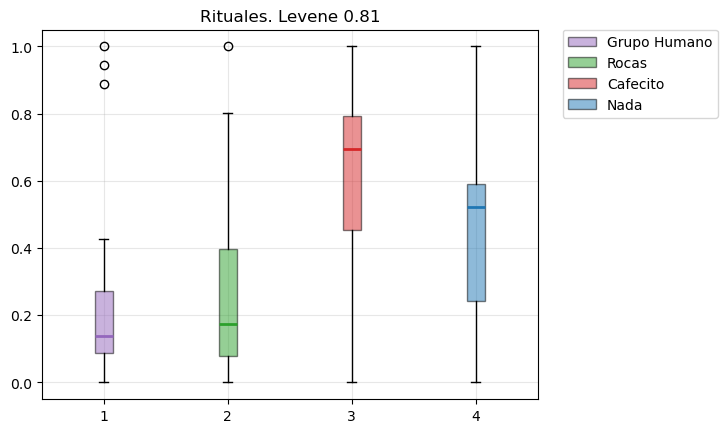

In [47]:
# Homocedasticidad
fig, ax = plt.subplots(dpi = 100)
colors = ['tab:purple', 'tab:green', 'tab:red', 'tab:blue']
rit = ['Grupo Humano', 'Rocas', 'Cafecito', 'Nada']
for i, data in enumerate([grupo_humano, rocas, cafecito, nada]):
    ax.boxplot(
        data,
        positions = [i+1],
        patch_artist = True,
        boxprops = dict( facecolor = colors[i], alpha = 0.5),
        medianprops = dict(color = colors[i], linewidth = 2),
        label = rit[i],
        zorder = 3
    )
ax.grid(alpha = 0.3, zorder = 0)
#
ax.legend(bbox_to_anchor = (1.05, 1), loc = 2, borderaxespad = 0.)
ax.set_xticks([1,2,3,4])
ax.set_title(f'Rituales. Levene {st.levene(grupo_humano, rocas, cafecito, nada).pvalue:.2f}')


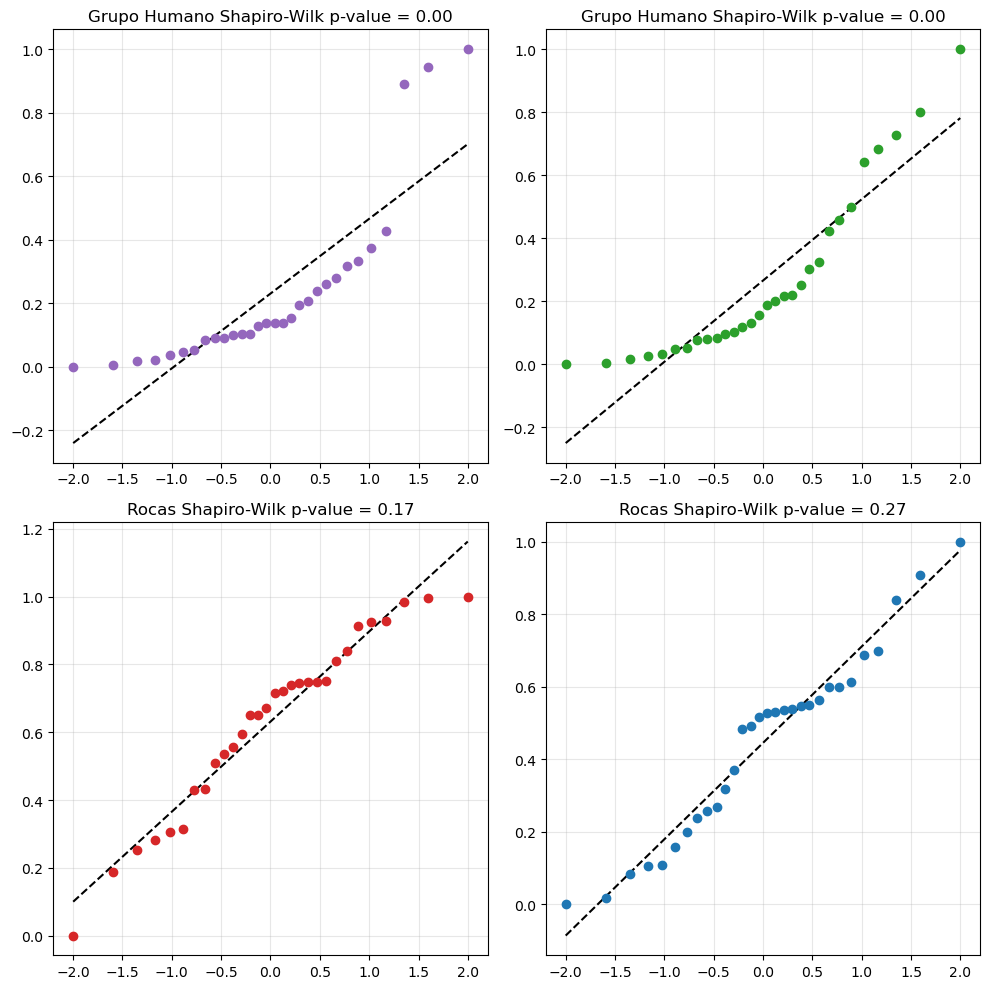

In [48]:
# Normalidad

fig, ax = plt.subplots(2,2,dpi = 100, figsize = (10,10))
colors = ['tab:purple', 'tab:green', 'tab:red', 'tab:blue']
rit = ['Grupo Humano', 'Rocas', 'Cafecito', 'Nada']
i, j = 0,0
for c, data in enumerate([grupo_humano, rocas, cafecito, nada]):
    shapiro_test = st.shapiro(data)
    (osm, osr), (slope, intercept, r) = st.probplot(data)
    ax[i,j].scatter(osm, osr, color = colors[c], zorder = 3)
    ax[i,j].plot(osm, slope*osm + intercept, color = 'k', linestyle = '--', zorder = 2)
    ax[i,j].grid(alpha = 0.3, zorder = 0)
    ax[i,j].set_title(f'{rit[i]} Shapiro-Wilk p-value = {shapiro_test.pvalue:.2f}')
    if j == 1:
        j = 0
        i += 1
    else:
        j += 1
fig.tight_layout()

# 2.
Realice un test estadístico que le permita comparar los efectos de los diferentes rituales a la
hora de dar una prueba. Justifique.

---

En este caso se realiza un test de kurskal wallis.

In [49]:
krusk = st.kruskal(
    grupo_humano, rocas, cafecito, nada
)
print(f'p-value: {krusk.pvalue}')


p-value: 2.5773621688536533e-07


Este test tiene la misma hipótesis que un test ANOVA, de forma que existen rituales con un efecto diferente.

## 3.
Realice un test estadístico que le permita evaluar cuál de los 4 rituales es el más eficaz y cuál es el que trae consigo los peores resultados. Justifique adecuadamente que test realizaría, tomando en cuenta los supuestos que este realiza.

---

En este caso realizamos un test MannWhitney U test para evaluar los diferentes datos debido a que al haber datos no-normales es necesario realizar tests no paramétricos.

In [50]:
rituales_df = pd.DataFrame(columns = ['Nota', 'Ritual'])
rituales_df['Nota'] = np.concatenate([grupo_humano, rocas, cafecito, nada])
rituales_df['Ritual'] = np.repeat(['Grupo Humano', 'Rocas', 'Cafecito', 'Nada'], 30)
pg.pairwise_tests(data = rituales_df, dv = 'Nota', between = 'Ritual', parametric = False,
                  padjust = 'bonf', alternative='greater', alpha = 0.05, correction = True)

,Contrast,A,B,Paired,Parametric,U_val,alternative,p_unc,p_corr,p_adjust,hedges
0,Ritual,Cafecito,Grupo Humano,False,False,766.0,greater,0.000002,0.000009,bonf,1.497880
1,Ritual,Cafecito,Nada,False,False,637.0,greater,0.002913,0.017480,bonf,0.705945
2,Ritual,Cafecito,Rocas,False,False,748.0,greater,0.000005,0.000033,bonf,1.359478
3,Ritual,Grupo Humano,Nada,False,False,227.0,greater,0.999524,1.000000,bonf,-0.801882
4,Ritual,Grupo Humano,Rocas,False,False,424.0,greater,0.652396,1.000000,bonf,-0.129963
5,Ritual,Nada,Rocas,False,False,632.0,greater,0.003643,0.021860,bonf,0.666547


Así, el cafecito siempre triunfa y apoya en momentos difíciles.